Data Collection & Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("adult.csv")

# Quick view
print(df.shape)      # rows, columns
print(df.dtypes)     # data types
df.head()


(48842, 15)
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


Data Understanding

In [23]:
# Shape of dataset
print("Shape:", df.shape)

# Column info
print(df.info())

# Summary stats for numeric columns
print(df.describe())

# Summary stats including categorical
print(df.describe(include="all"))

# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicates
print("Duplicates:", df.duplicated().sum())


Shape: (48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None
                age        fnlwgt  educational-num  

Data Cleaning

In [24]:
# Fill missing values
# Safe way to fill without warning
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


# Drop duplicates
df = df.drop_duplicates()

# Convert column type (example: date column)
# df['date'] = pd.to_datetime(df['date'])

print("After cleaning:", df.shape)


After cleaning: (48790, 15)


Rule of Thumb:

Numerical vs Numerical → Scatter Plot ✅
(age vs hours, capital-gain vs hours, etc.)

Categorical vs Numerical → Boxplot / Barplot ✅
(income vs age, education vs age, etc.)

Categorical vs Categorical → Countplot ✅
(gender vs income, workclass vs income, etc.)

More than 2 variables → Colored Scatter, FacetGrid, Pairplot ✅

Univariate Analysis (one variable at a time)

  Category  Value
0        A      5
1        A      7
2        A      6
3        B      8
4        B      7
5        B      9
6        C      4
7        C      3
8        C      5


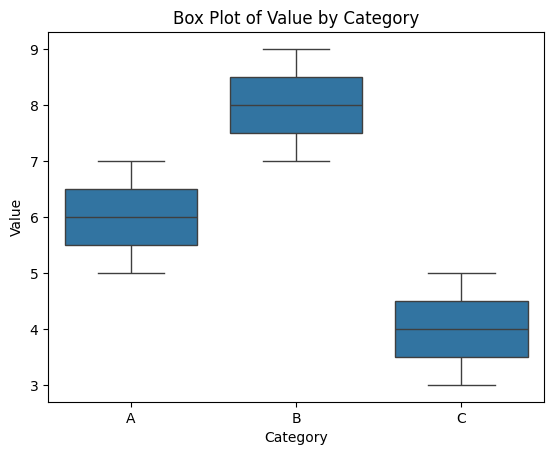

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example dataset
df = pd.DataFrame({
    "Category": ["A", "A", "A", "B", "B", "B", "C", "C", "C"],
    "Value": [5, 7, 6, 8, 7, 9, 4, 3, 5]
})

print(df)

# Create box plot
sns.boxplot(x="Category", y="Value", data=df)
plt.title("Box Plot of Value by Category")
plt.show()


🔹 What the box plot shows:

X-axis → Categorical variable (Category: A, B, C)

Y-axis → Numerical variable (Value)

Each box shows:

Median (line inside box)

Q1 and Q3 (box edges = 25th and 75th percentiles)

Whiskers (spread of data, usually 1.5×IQR)

Outliers (points outside whiskers)

So you can easily compare how the distribution of Value changes across categories A, B, and C.

   Gender Preference
0    Male        Tea
1  Female     Coffee
2  Female        Tea
3    Male        Tea
4    Male     Coffee
5  Female     Coffee
6  Female        Tea
7    Male     Coffee


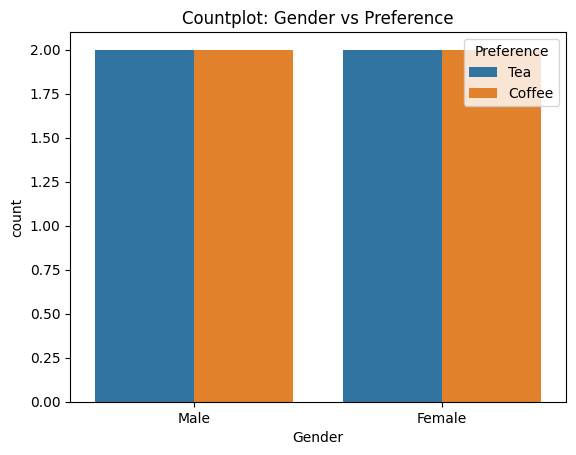

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example dataset
df = pd.DataFrame({
    "Gender": ["Male", "Female", "Female", "Male", "Male", "Female", "Female", "Male"],
    "Preference": ["Tea", "Coffee", "Tea", "Tea", "Coffee", "Coffee", "Tea", "Coffee"]
})

print(df)

# Countplot for Categorical vs Categorical
sns.countplot(x="Gender", hue="Preference", data=df)
plt.title("Countplot: Gender vs Preference")
plt.show()


In [27]:
df = pd.read_csv("adult.csv")

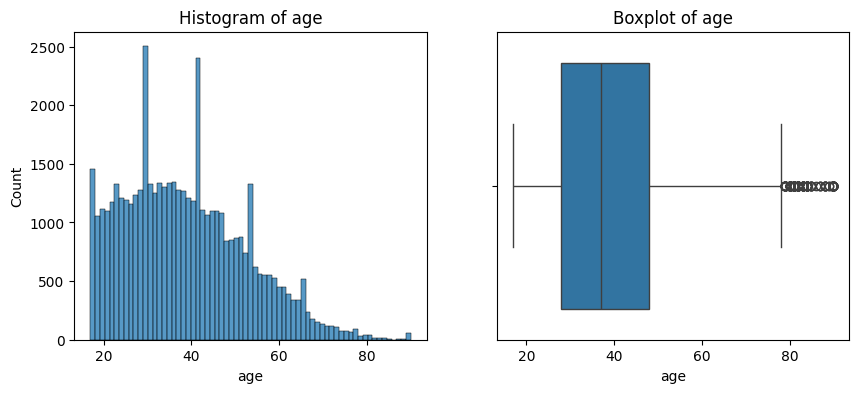

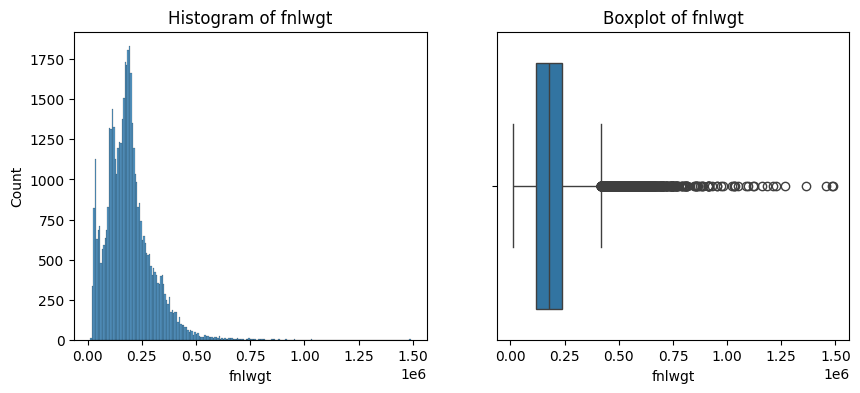

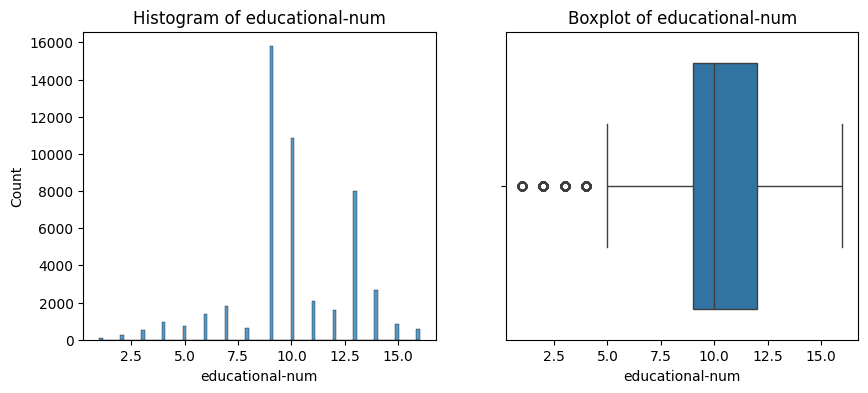

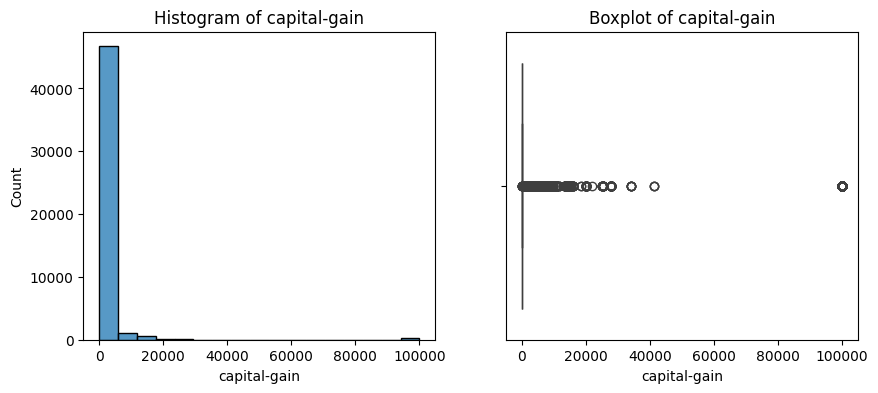

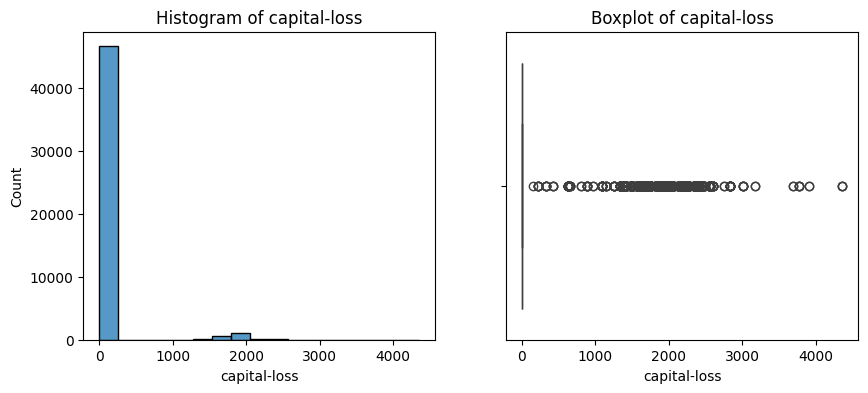

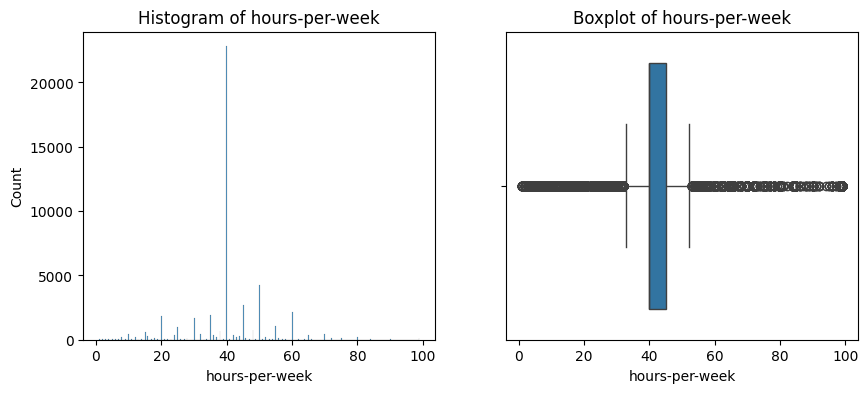

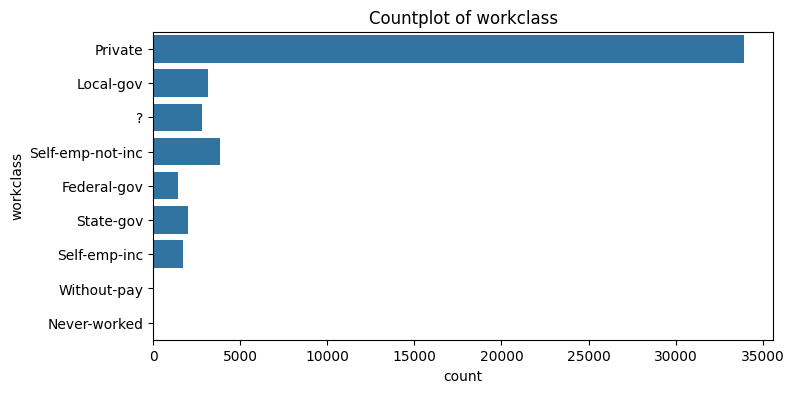

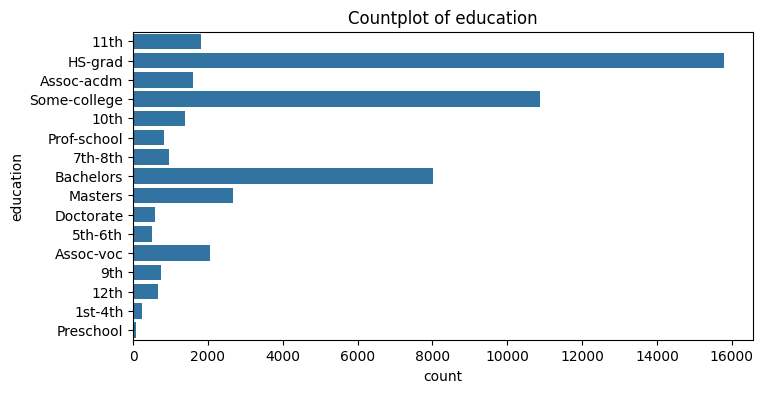

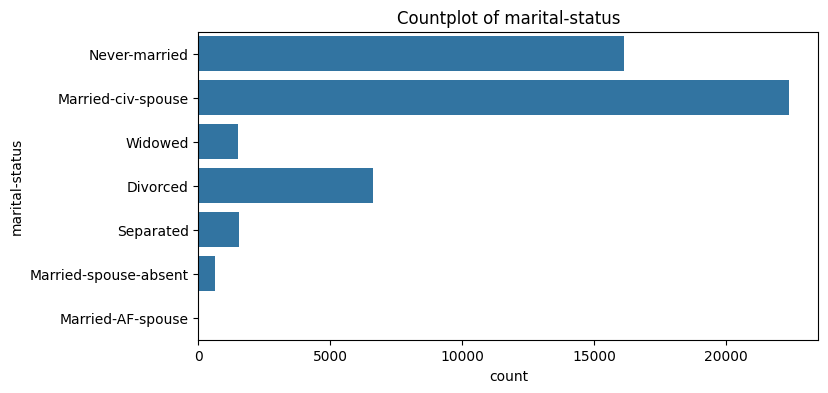

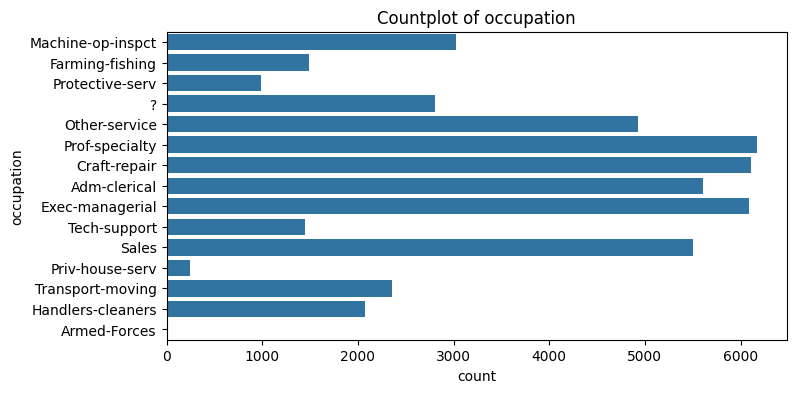

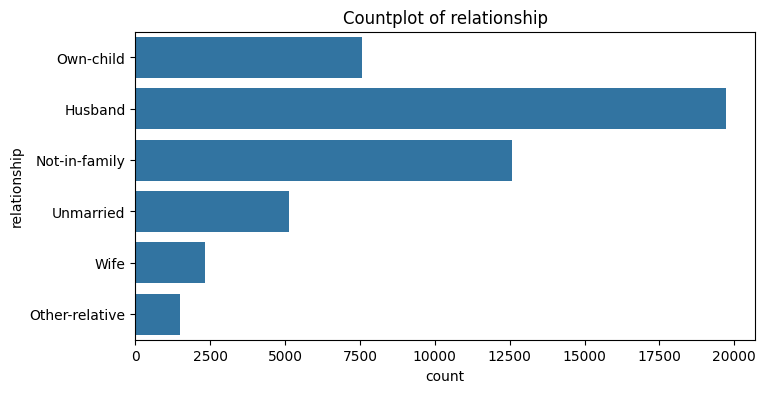

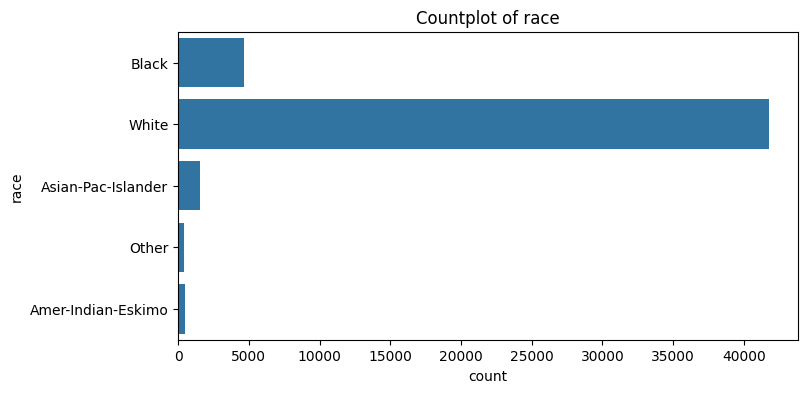

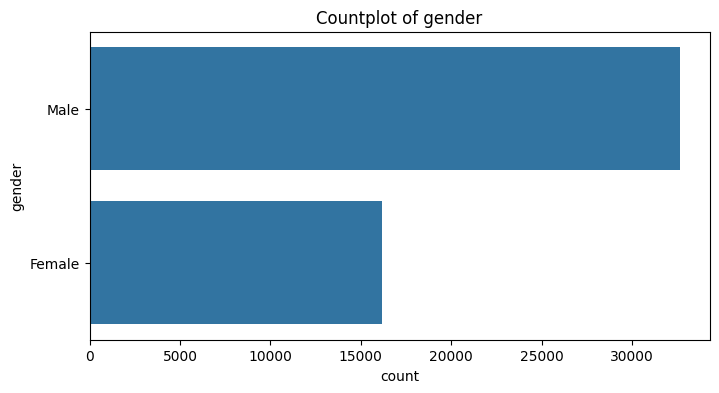

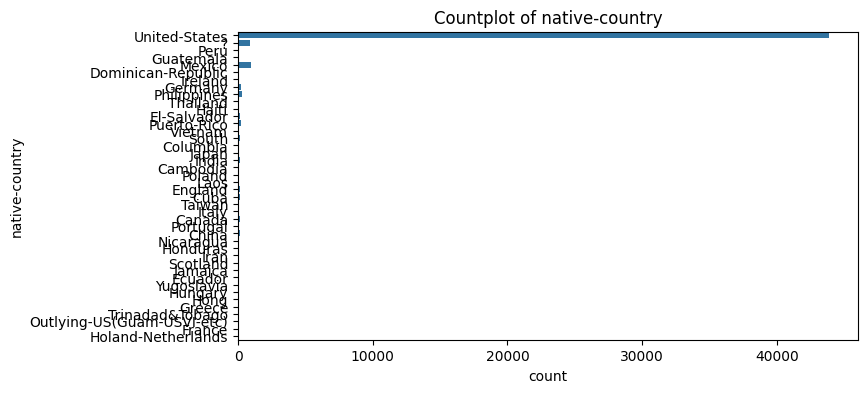

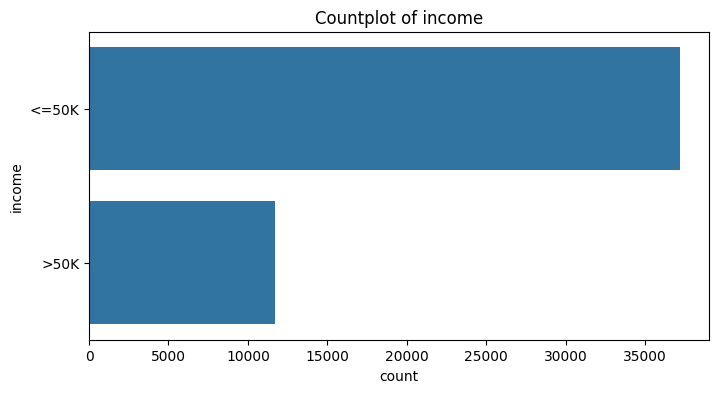

In [28]:
# Numerical features - histogram + boxplot
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.histplot(df[col])
    plt.title(f"Histogram of {col}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    
    plt.show()

# Categorical features - count plot
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col]) # y just tells axis
    plt.title(f"Countplot of {col}")
    plt.show()


***Bivariate Analysis (two variables)***

Numerical vs Target (Income) 


In [29]:
df.groupby('income')['age'].mean()

income
<=50K    36.872184
>50K     44.275178
Name: age, dtype: float64

In [30]:
type(df.groupby('income')['age'].mean())

pandas.core.series.Series

In [31]:
type(df.groupby('income')['age'].mean().reset_index())

pandas.core.frame.DataFrame

data should be dataframe in sns.barplot

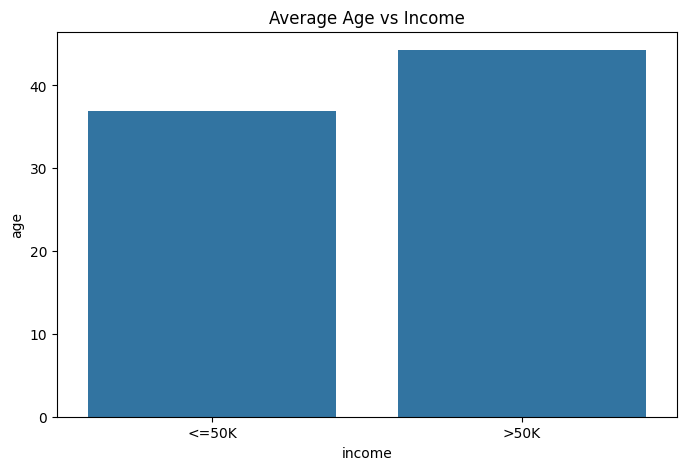

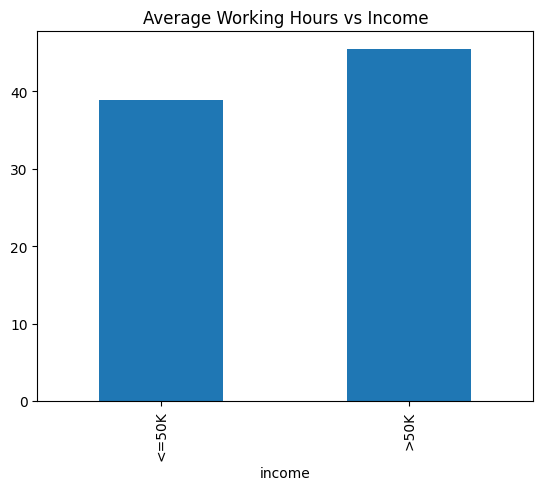

In [32]:
import matplotlib.pyplot as plt

# Age vs Income
t = df.groupby('income')['age'].mean().reset_index()
plt.figure(figsize=[8,5])
sns.barplot(x='income', y='age', data=t)
plt.title("Average Age vs Income")
plt.show()

# Hours per week vs Income
df.groupby('income')['hours-per-week'].mean().plot(kind='bar')
plt.title("Average Working Hours vs Income")
plt.show()


Categorical vs Target (Income) 

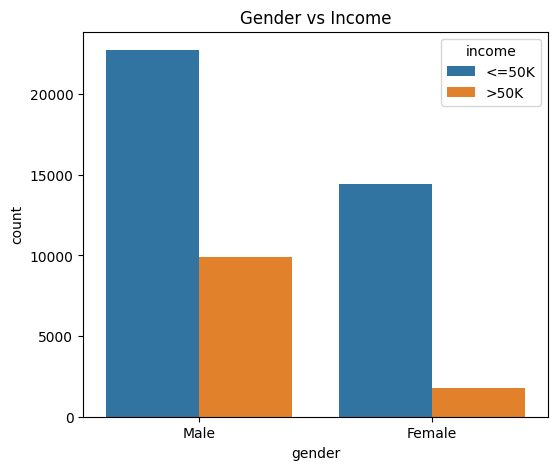

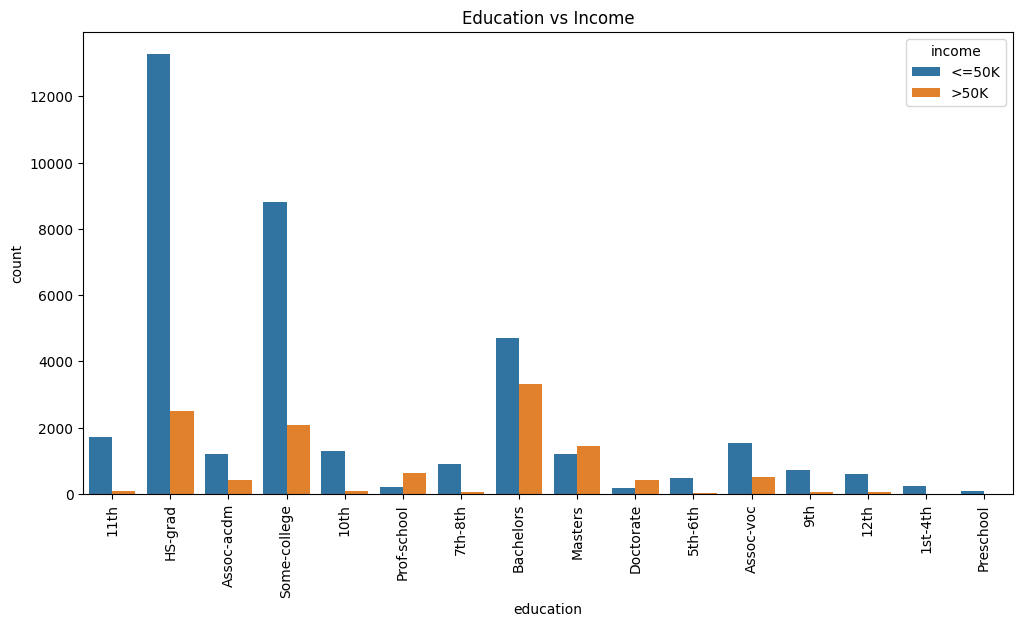

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gender vs Income
plt.figure(figsize=(6,5))
sns.countplot(x="gender", hue="income", data=df)
plt.title("Gender vs Income")
plt.show()

# Education vs Income
plt.figure(figsize=(12,6))
sns.countplot(x="education", hue="income", data=df)
plt.title("Education vs Income")
plt.xticks(rotation=90)   # rotate labels for readability
plt.show()


Two Numericals Together (Correlation) 

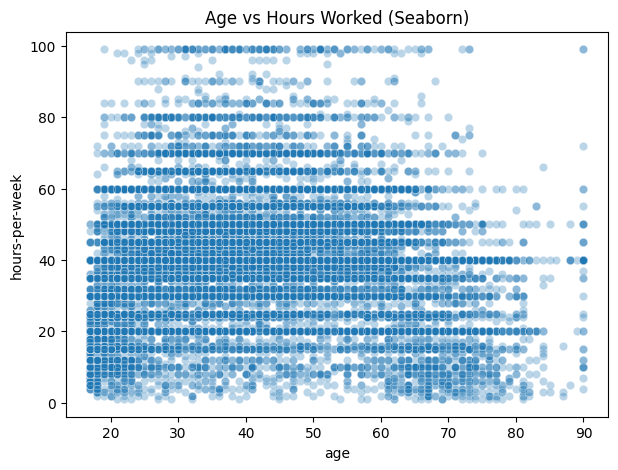

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation between age and hours-per-week using scatterplot
plt.figure(figsize=(7,5))
sns.scatterplot(x="age", y="hours-per-week", data=df, alpha=0.3)
plt.title("Age vs Hours Worked (Seaborn)")
plt.show()


***Multivariate Analysis***

Age + Hours-per-week + Income

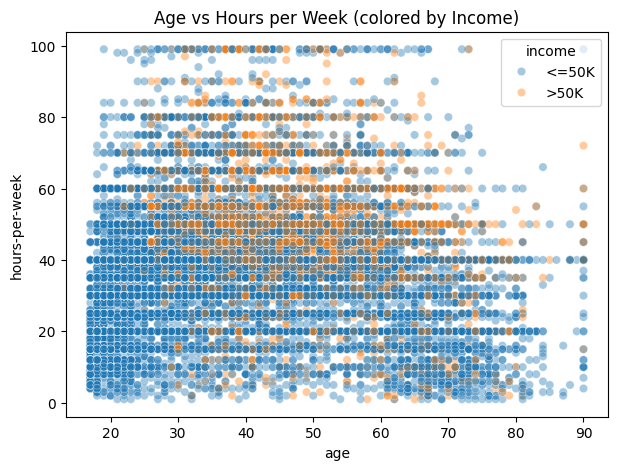

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.scatterplot(x="age", y="hours-per-week", hue="income", data=df, alpha=0.4)
plt.title("Age vs Hours per Week (colored by Income)")
plt.show()


Education + Marital-status + Income

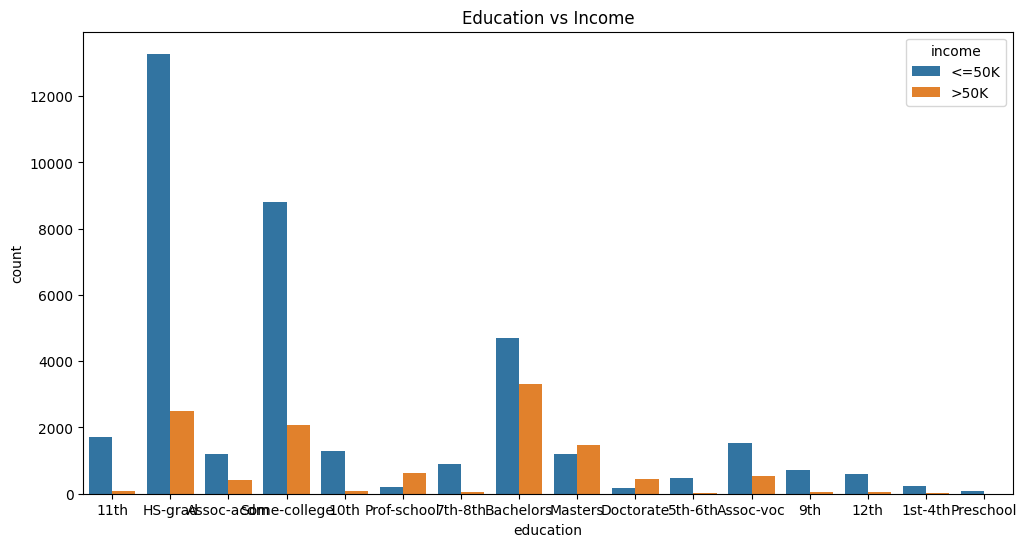

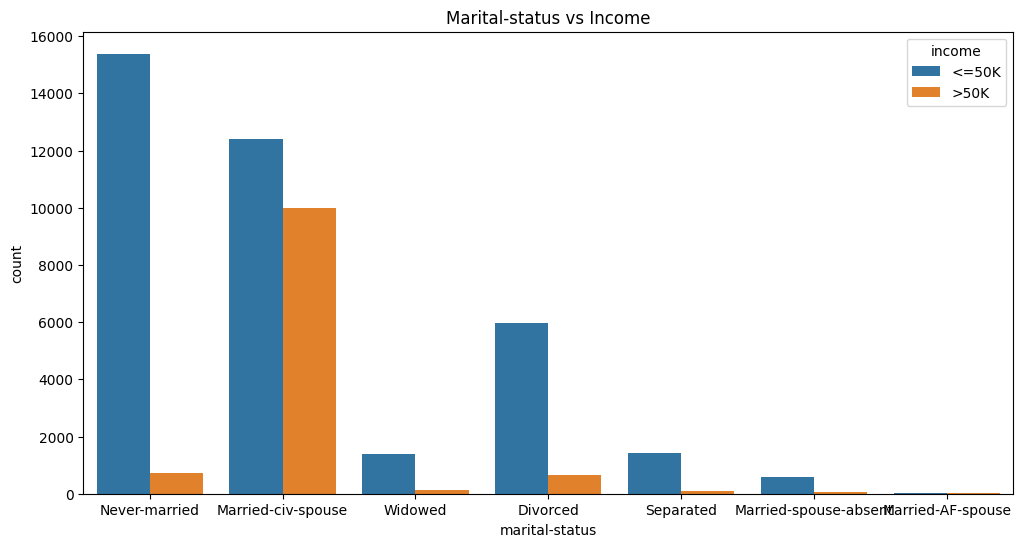

In [36]:
plt.figure(figsize=(12,6))
sns.countplot(x="education", hue="income", data=df)
plt.title("Education vs Income")
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(x="marital-status", hue="income", data=df)
plt.title("Marital-status vs Income")
plt.show()


Workclass + Occupation + Income

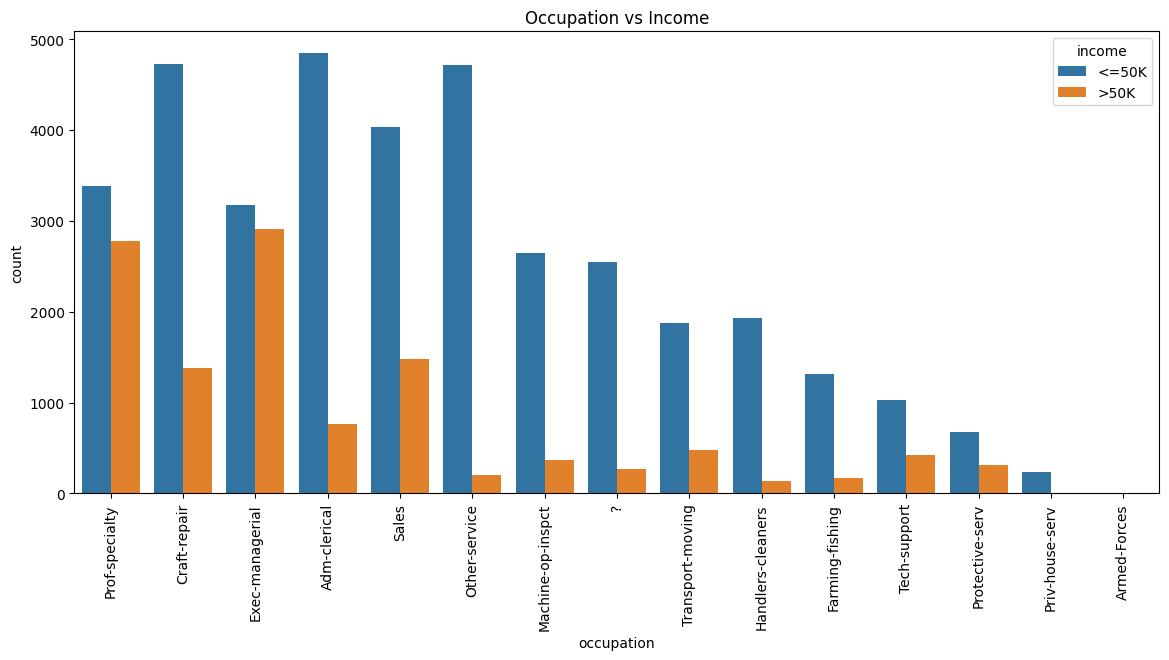

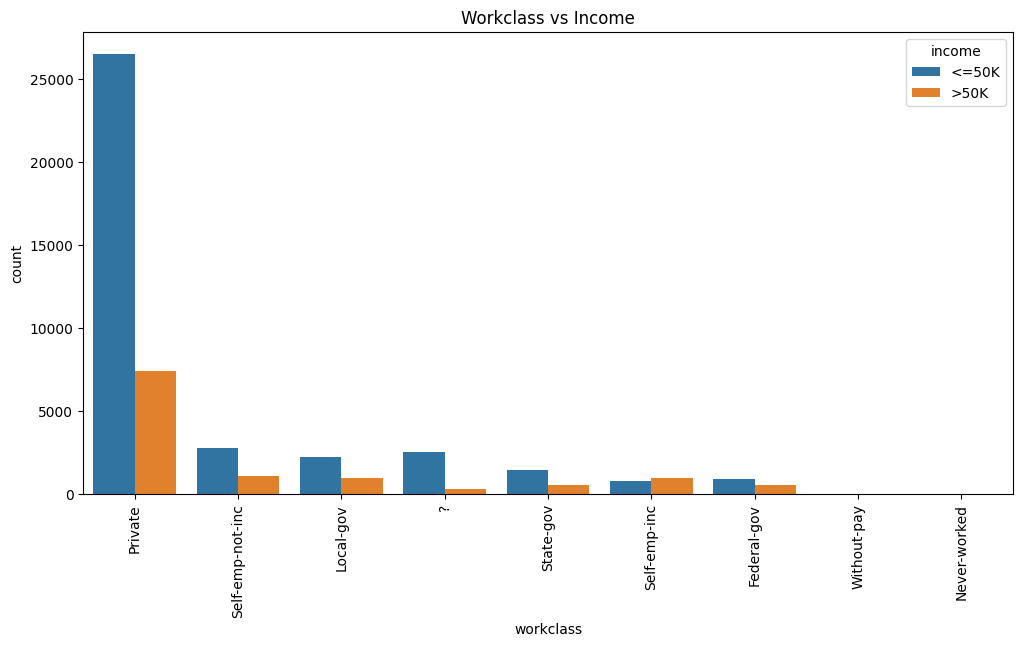

In [37]:
plt.figure(figsize=(14,6))
sns.countplot(x="occupation", hue="income", data=df, order=df["occupation"].value_counts().index)
plt.title("Occupation vs Income")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(x="workclass", hue="income", data=df, order=df["workclass"].value_counts().index)
plt.title("Workclass vs Income")
plt.xticks(rotation=90)
plt.show()


Gender + Race + Income

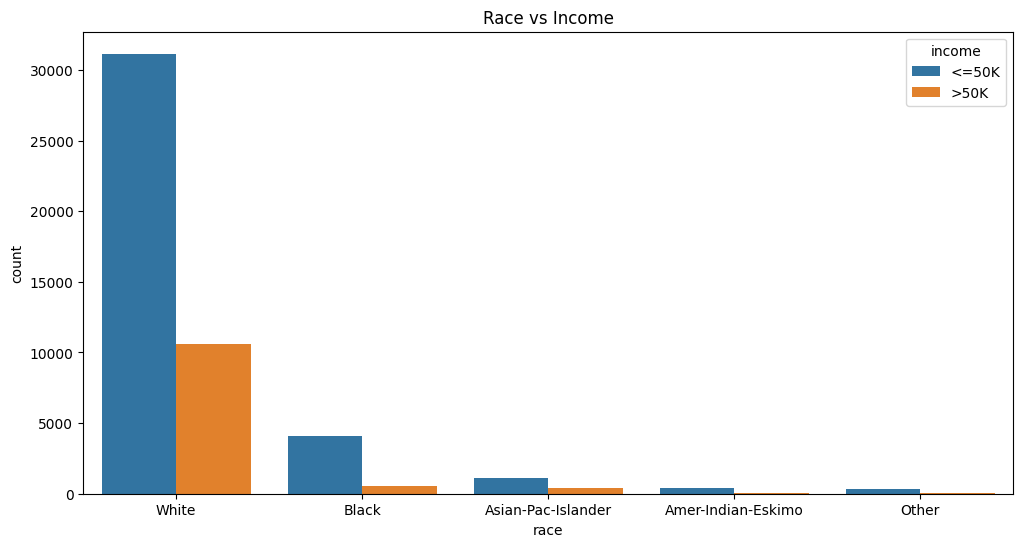

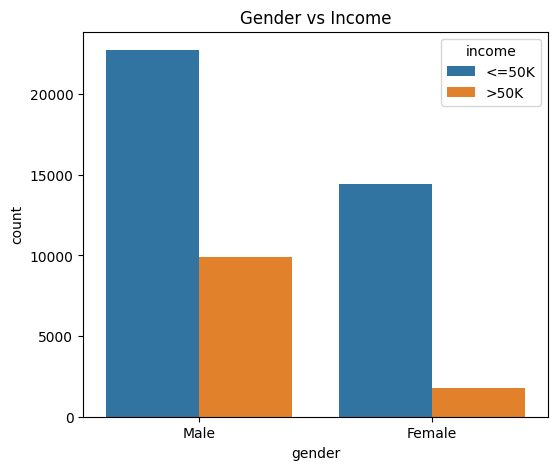

In [38]:
plt.figure(figsize=(12,6))
sns.countplot(x="race", hue="income", data=df, order=df["race"].value_counts().index)
plt.title("Race vs Income")
plt.show()

plt.figure(figsize=(6,5))
sns.countplot(x="gender", hue="income", data=df)
plt.title("Gender vs Income")
plt.show()
